<a href="https://colab.research.google.com/github/punhodik/SQL-e-commerce-data-base-analysis/blob/main/Exploratory_data_analysis_for_online_store.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount("/content/drive")
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


Mounted at /content/drive


In [ ]:
%cd /content/drive/MyDrive/Python
events_data = pd.read_csv("events.csv")
events_data.head()

/content/drive/MyDrive/Python


,Order ID,Order Date,Ship Date,Order Priority,Country Code,Product ID,Sales Channel,Units Sold,Unit Price,Unit Cost
0,100640618,10/8/2014,10/18/2014,M,NOR,2103,Online,650.0,205.70,117.11
1,100983083,8/11/2016,8/11/2016,C,SRB,2103,Offline,1993.0,205.70,117.11
2,101025998,7/18/2014,8/11/2014,M,NaN,7940,Online,4693.0,668.27,502.54
3,102230632,5/13/2017,6/13/2017,L,MNE,2455,Online,1171.0,109.28,35.84
4,103435266,8/11/2012,9/18/2012,H,SRB,1270,Offline,7648.0,47.45,31.79


In [ ]:
events_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1330 entries, 0 to 1329
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Order ID        1330 non-null   int64  
 1   Order Date      1330 non-null   object 
 2   Ship Date       1330 non-null   object 
 3   Order Priority  1330 non-null   object 
 4   Country Code    1248 non-null   object 
 5   Product ID      1330 non-null   int64  
 6   Sales Channel   1330 non-null   object 
 7   Units Sold      1328 non-null   float64
 8   Unit Price      1330 non-null   float64
 9   Unit Cost       1330 non-null   float64
dtypes: float64(3), int64(2), object(5)
memory usage: 104.0+ KB


In [ ]:
events_data.describe()

,Order ID,Product ID,Units Sold,Unit Price,Unit Cost
count,1.330000e+03,1330.000000,1328.000000,1330.000000,1330.000000
mean,5.412048e+08,5788.096241,4952.201807,264.893541,187.246812
std,2.573882e+08,2820.728878,2905.198996,217.323460,176.158873
min,1.006406e+08,1270.000000,2.000000,9.330000,6.920000
25%,3.190004e+08,3127.000000,2356.750000,81.730000,35.840000
50%,5.387164e+08,5988.000000,4962.000000,154.060000,97.440000
75%,7.544628e+08,8681.000000,7459.500000,437.200000,263.330000
max,9.998797e+08,8969.000000,9999.000000,668.270000,524.960000


In [ ]:
%cd /content/drive/MyDrive/Python
countries_data = pd.read_csv("countries.csv")
countries_data.head()

/content/drive/MyDrive/Python


,name,alpha-2,alpha-3,region,sub-region
0,Afghanistan,AF,AFG,Asia,Southern Asia
1,Åland Islands,AX,ALA,Europe,Northern Europe
2,Albania,AL,ALB,Europe,Southern Europe
3,Algeria,DZ,DZA,Africa,Northern Africa
4,American Samoa,AS,ASM,Oceania,Polynesia


In [ ]:
countries_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 249 entries, 0 to 248
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   name        249 non-null    object
 1   alpha-2     248 non-null    object
 2   alpha-3     249 non-null    object
 3   region      248 non-null    object
 4   sub-region  248 non-null    object
dtypes: object(5)
memory usage: 9.9+ KB


In [ ]:
%cd /content/drive/MyDrive/Python
products_data = pd.read_csv("products.csv")
products_data

/content/drive/MyDrive/Python


,id,item_type
0,2103,Cereal
1,7940,Household
2,2455,Clothes
3,1270,Beverages
4,8681,Office Supplies
5,4594,Fruits
6,5988,Vegetables
7,7331,Baby Food
8,8875,Meat
9,8293,Cosmetics


In [ ]:
products_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   id         12 non-null     int64 
 1   item_type  12 non-null     object
dtypes: int64(1), object(1)
memory usage: 324.0+ bytes


## Data overview
- The first data frame, *event_data*, contains all order data for the last few years. In this table, also has to be changed the type of the **Order Date** and **Ship Date** columns and dealt with missing values. There are **1330** records in total in the data frame. On average, **4952** items are sold per order, and the largest number of items sold was **9999**.
- The following table *countries_data* contains all data related to the countries of origin (country names, their codes in two variants, regions and subregions where they are located). There are **1330** records in total in the data frame. There are also missing values in this table. The *event_data* and *countries_data* tables have a common column called “**Country Code**,” which is called “**alpha-3**” in the second table.
- The last table is the smallest, with only **12** records. It contains a list of categories of goods that are ordered. There are **no** **missing** values. The *event_data* and *products_data* tables have a common column called “**Product ID**,” which is called “**id**” in the second table.

In [ ]:
pct_null_values_events = events_data.isna().sum()/events_data.shape[0]*100
pct_null_values_events

,0
Order ID,0.000000
Order Date,0.000000
Ship Date,0.000000
Order Priority,0.000000
Country Code,6.165414
Product ID,0.000000
Sales Channel,0.000000
Units Sold,0.150376
Unit Price,0.000000
Unit Cost,0.000000


## Data cleaning

**6%** of missing values were found in the **Country Code** column. These missing values are country codes that may have been provided in a different format (for example, in alpha-2 format instead of alpha-3), which is why they were not recorded in the corresponding column. Since this column links the events_data table to the countries_data table, in order not to distort subsequent calculations, it was decided to **delete all records** with missing values in the above-mentioned column.  
There were also **0.15%** missing entries in the **Units Sold** column, which could be explained by a system failure, a bug, or human error (carelessness). It was decided to **delete records** with missing values in the above-mentioned column, since such a negligible percentage of records does not affect the overall picture of the analysis.

In [ ]:
events_data.dropna(inplace=True)

In [ ]:
events_data.isna().sum()

,0
Order ID,0
Order Date,0
Ship Date,0
Order Priority,0
Country Code,0
Product ID,0
Sales Channel,0
Units Sold,0
Unit Price,0
Unit Cost,0


In [ ]:
pct_null_values_countries = countries_data.isna().sum()/countries_data.shape[0]*100
pct_null_values_countries

,0
name,0.000000
alpha-2,0.401606
alpha-3,0.000000
region,0.401606
sub-region,0.401606


In [ ]:
missing_rows = countries_data[countries_data['sub-region'].isna()]
missing_rows

,name,alpha-2,alpha-3,region,sub-region
8,Antarctica,AQ,ATA,NaN,NaN


In [ ]:
missing_rows1 = countries_data[countries_data['alpha-2'].isna()]
missing_rows1

,name,alpha-2,alpha-3,region,sub-region
153,Namibia,NaN,NAM,Africa,Sub-Saharan Africa


In [ ]:
cell = events_data["Country Code"] == "NAM"
count = cell.sum()
count

np.int64(0)

In [ ]:
cell1 = events_data["Country Code"] == "ATA"
count1 = cell1.sum()
count1

np.int64(0)

After a series of checks, it was established that the *events_data* table **does not** contain orders to countries with a Country Code equal to **NAM**  or **ATA**. This means that records with these countries in the countries_data table are not important. Therefore, it was decided to simply delete the rows containing the missing values from the countries_data table.

In [ ]:
countries_data.dropna(inplace=True)

In [ ]:
countries_data.isna().sum()

,0
name,0
alpha-2,0
alpha-3,0
region,0
sub-region,0


In [ ]:
events_data["Order Date"] = pd.to_datetime(events_data["Order Date"])
events_data["Ship Date"] = pd.to_datetime(events_data["Ship Date"])

In [ ]:
events_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1246 entries, 0 to 1329
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Order ID        1246 non-null   int64         
 1   Order Date      1246 non-null   datetime64[ns]
 2   Ship Date       1246 non-null   datetime64[ns]
 3   Order Priority  1246 non-null   object        
 4   Country Code    1246 non-null   object        
 5   Product ID      1246 non-null   int64         
 6   Sales Channel   1246 non-null   object        
 7   Units Sold      1246 non-null   float64       
 8   Unit Price      1246 non-null   float64       
 9   Unit Cost       1246 non-null   float64       
dtypes: datetime64[ns](2), float64(3), int64(2), object(3)
memory usage: 107.1+ KB


In [ ]:
duplicate_rows_events = events_data.duplicated()
duplicate_rows_events.sum()

np.int64(0)

In [ ]:
duplicate_rows_countries = countries_data.duplicated()
duplicate_rows_countries.sum()

np.int64(0)

In [ ]:
duplicate_rows_products = products_data.duplicated()
duplicate_rows_products.sum()

np.int64(0)

In [ ]:
events_data["Order ID"].nunique()

1246

In [ ]:
for col in events_data.columns:
    if events_data[col].dtype == 'object':
        events_data[col] = events_data[col].str.strip()

In [ ]:
for col in events_data.columns:
    if events_data[col].dtype == 'object':
        events_data[col] = events_data[col].str.replace(r'\s+', ' ', regex=True)

In [ ]:
for col in events_data.columns:
    if events_data[col].dtype == 'object':
        events_data[col] = events_data[col].str.replace(r'[^A-Za-z0-9 ]', '', regex=True)

In [ ]:
for col in events_data.columns:
    if events_data[col].dtype == 'object':
        events_data[col] = events_data[col].str.upper()

In [ ]:
for col in events_data.columns:
    if events_data[col].dtype == 'object':
        print(f"Unique value of the column {col}:")
        print(events_data[col].unique())
        print("-" * 40)

Unique value of the column Order Priority:
['M' 'C' 'L' 'H']
----------------------------------------
Unique value of the column Country Code:
['NOR' 'SRB' 'MNE' 'SVK' 'FRA' 'ESP' 'HRV' 'DEU' 'ARM' 'GEO' 'GBR' 'SVN'
 'ROU' 'POL' 'LUX' 'CYP' 'BEL' 'LTU' 'RUS' 'MLT' 'UKR' 'CZE' 'PRT' 'BLR'
 'EST' 'AUT' 'MKD' 'SMR' 'NLD' 'CHE' 'HUN' 'LVA' 'BGR' 'ITA' 'IRL' 'AND'
 'LIE' 'FIN' 'ALB' 'SWE' 'BIH' 'DNK' 'MCO' 'ISL' 'GRC']
----------------------------------------
Unique value of the column Sales Channel:
['ONLINE' 'OFFLINE']
----------------------------------------


In [ ]:
for col in events_data.columns:
    if events_data[col].dtype == 'object':
        mask = events_data[col].str.contains(r'[А-Яа-я]', na=False)
        if mask.any():
            print(f"Column {col} :")
            print(events_data.loc[mask, col])
            print("-" * 40)


In [ ]:
for col in countries_data.columns:
    if countries_data[col].dtype == 'object':
        countries_data[col] = countries_data[col].str.strip()

In [ ]:
for col in countries_data.columns:
    if countries_data[col].dtype == 'object':
        countries_data[col] = countries_data[col].str.replace(r'\s+', ' ', regex=True)

In [ ]:
for col in countries_data.columns:
    if countries_data[col].dtype == 'object':
        countries_data[col] = countries_data[col].str.replace(r'[^A-Za-z0-9 ]', '', regex=True)

In [ ]:
for col in countries_data.columns:
    if countries_data[col].dtype == 'object':
        countries_data[col] = countries_data[col].str.upper()

In [ ]:
for col in countries_data.columns:
    if countries_data[col].dtype == 'object':
        mask = countries_data[col].str.contains(r'[А-Яа-я]', na=False)
        if mask.any():
            print(f"Column {col} :")
            print(countries_data.loc[mask, col])
            print("-" * 40)

In [ ]:
for col in countries_data.columns:
    if countries_data[col].dtype == 'object':
        print(f"Unique values of the column named {col}:")
        print(countries_data[col].nunique())
        print("-" * 40)

Unique values of the column named Country:
247
----------------------------------------
Unique values of the column named Country Code:
247
----------------------------------------
Unique values of the column named Region:
5
----------------------------------------
Unique values of the column named Sub-Region:
17
----------------------------------------


Above, a check for duplicates was performed on all three tables, then, in case of inaccuracies, spaces at the beginning and end of the line were removed, several spaces were replaced with a single space, unwanted characters were deleted, all object values were converted to uppercase, and the records were checked for Cyrillic letters, which were not found.

<Axes: xlabel='Units Sold'>

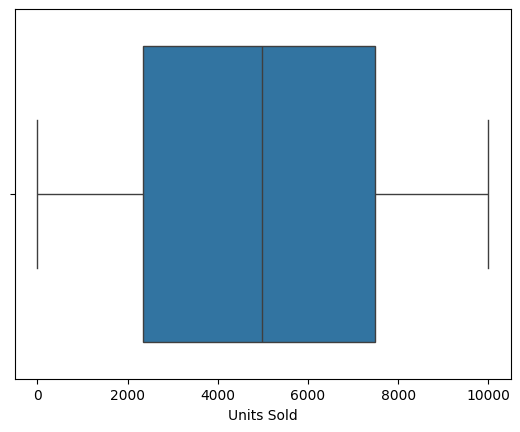

In [ ]:
sns.boxplot(x = events_data["Units Sold"])

<Axes: xlabel='Unit Price'>

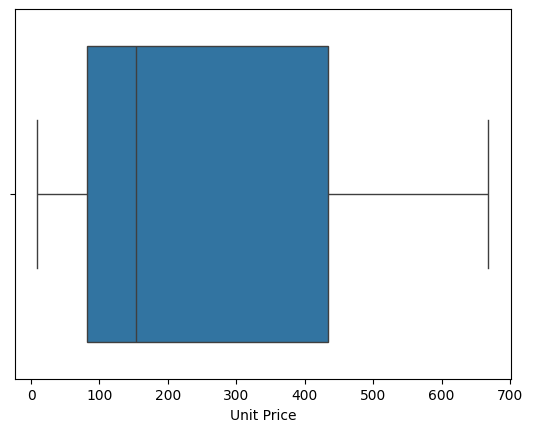

In [ ]:
sns.boxplot(x = events_data["Unit Price"])

<Axes: xlabel='Unit Cost'>

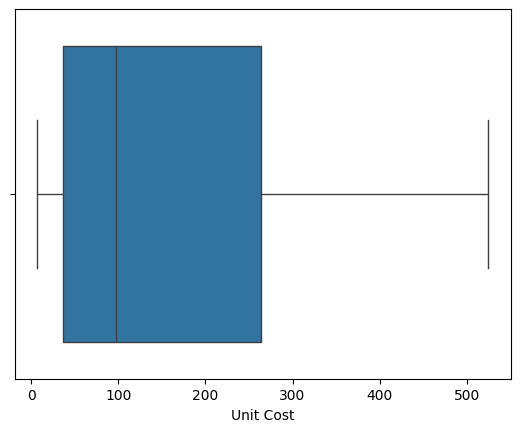

In [ ]:
sns.boxplot(x = events_data["Unit Cost"])

According to the statistical method of anomaly verification, the graphs show that there are no outliers, i.e., anomalies, outside the whiskers. Therefore, we can conclude that there are **no** outliers in the tables.

In [ ]:
countries_data.head()

,name,alpha-2,alpha-3,region,sub-region
0,AFGHANISTAN,AF,AFG,ASIA,SOUTHERN ASIA
1,LAND ISLANDS,AX,ALA,EUROPE,NORTHERN EUROPE
2,ALBANIA,AL,ALB,EUROPE,SOUTHERN EUROPE
3,ALGERIA,DZ,DZA,AFRICA,NORTHERN AFRICA
4,AMERICAN SAMOA,AS,ASM,OCEANIA,POLYNESIA


In [ ]:
countries_data.columns = countries_data.columns.str.title()
countries_data.head()

,Name,Alpha-2,Alpha-3,Region,Sub-Region
0,AFGHANISTAN,AF,AFG,ASIA,SOUTHERN ASIA
1,LAND ISLANDS,AX,ALA,EUROPE,NORTHERN EUROPE
2,ALBANIA,AL,ALB,EUROPE,SOUTHERN EUROPE
3,ALGERIA,DZ,DZA,AFRICA,NORTHERN AFRICA
4,AMERICAN SAMOA,AS,ASM,OCEANIA,POLYNESIA


In [ ]:
products_data.columns = products_data.columns.str.title()
products_data.head()

,Id,Item_Type
0,2103,Cereal
1,7940,Household
2,2455,Clothes
3,1270,Beverages
4,8681,Office Supplies


In [ ]:
countries_data = countries_data.rename(columns={"Alpha-3":"Country Code"})

In [ ]:
countries_data = countries_data.rename(columns={"Name":"Country"})

In [ ]:
products_data = products_data.rename(columns = {"Id": "Product ID"})

In [ ]:
products_data.head()

,Product ID,Item_Type
0,2103,Cereal
1,7940,Household
2,2455,Clothes
3,1270,Beverages
4,8681,Office Supplies


In [ ]:
countries_data = countries_data.drop(columns=["Alpha-2"])

In [ ]:
countries_data.head()

,Country,Country Code,Region,Sub-Region
0,AFGHANISTAN,AFG,ASIA,SOUTHERN ASIA
1,LAND ISLANDS,ALA,EUROPE,NORTHERN EUROPE
2,ALBANIA,ALB,EUROPE,SOUTHERN EUROPE
3,ALGERIA,DZA,AFRICA,NORTHERN AFRICA
4,AMERICAN SAMOA,ASM,OCEANIA,POLYNESIA


In [ ]:
full_df = events_data.merge(countries_data, on = "Country Code", how = "outer").merge(products_data, on = "Product ID", how = "outer")
full_df.head()

,Order ID,Order Date,Ship Date,Order Priority,Country Code,Product ID,Sales Channel,Units Sold,Unit Price,Unit Cost,Country,Region,Sub-Region,Item_Type
0,270358788.0,2014-12-11,2015-01-24,M,ALB,1270.0,OFFLINE,4028.0,47.45,31.79,ALBANIA,EUROPE,SOUTHERN EUROPE,Beverages
1,833473765.0,2013-04-28,2013-05-25,H,ALB,1270.0,OFFLINE,2264.0,47.45,31.79,ALBANIA,EUROPE,SOUTHERN EUROPE,Beverages
2,877062451.0,2012-10-09,2012-10-29,C,ALB,1270.0,ONLINE,1124.0,47.45,31.79,ALBANIA,EUROPE,SOUTHERN EUROPE,Beverages
3,320431125.0,2015-03-11,2015-04-17,H,AND,1270.0,ONLINE,1545.0,47.45,31.79,ANDORRA,EUROPE,SOUTHERN EUROPE,Beverages
4,378873240.0,2012-11-25,2012-11-28,H,AND,1270.0,ONLINE,5866.0,47.45,31.79,ANDORRA,EUROPE,SOUTHERN EUROPE,Beverages


In [ ]:
total_quantities = full_df["Units Sold"].sum()
print(f"Total Sales: {total_quantities}")

Total Sales: 6171671.0


In [ ]:
number_of_countries = full_df["Country"].nunique()
print(f"Countries: {number_of_countries}")

Countries: 247


In [ ]:
revenue = full_df["Units Sold"]*full_df["Unit Price"]
full_df["Revenue"] = revenue
full_df.head()

,Order ID,Order Date,Ship Date,Order Priority,Country Code,Product ID,Sales Channel,Units Sold,Unit Price,Unit Cost,Country,Region,Sub-Region,Item_Type,Revenue
0,270358788.0,2014-12-11,2015-01-24,M,ALB,1270.0,OFFLINE,4028.0,47.45,31.79,ALBANIA,EUROPE,SOUTHERN EUROPE,Beverages,191128.60
1,833473765.0,2013-04-28,2013-05-25,H,ALB,1270.0,OFFLINE,2264.0,47.45,31.79,ALBANIA,EUROPE,SOUTHERN EUROPE,Beverages,107426.80
2,877062451.0,2012-10-09,2012-10-29,C,ALB,1270.0,ONLINE,1124.0,47.45,31.79,ALBANIA,EUROPE,SOUTHERN EUROPE,Beverages,53333.80
3,320431125.0,2015-03-11,2015-04-17,H,AND,1270.0,ONLINE,1545.0,47.45,31.79,ANDORRA,EUROPE,SOUTHERN EUROPE,Beverages,73310.25
4,378873240.0,2012-11-25,2012-11-28,H,AND,1270.0,ONLINE,5866.0,47.45,31.79,ANDORRA,EUROPE,SOUTHERN EUROPE,Beverages,278341.70


In [ ]:
start_date = full_df["Order Date"].min()
end_date = full_df["Order Date"].max()
start_date, end_date

(Timestamp('2010-01-01 00:00:00'), Timestamp('2017-07-22 00:00:00'))

In [ ]:
total_revenue = full_df["Revenue"].sum()
print(f"Total Revenue: {total_revenue}")

Total Revenue: 1598983761.26


In [ ]:
full_costs = full_df["Units Sold"]*full_df["Unit Cost"]
full_df["Cost"] = full_costs
full_df.head()

,Order ID,Order Date,Ship Date,Order Priority,Country Code,Product ID,Sales Channel,Units Sold,Unit Price,Unit Cost,Country,Region,Sub-Region,Item_Type,Revenue,Cost
0,270358788.0,2014-12-11,2015-01-24,M,ALB,1270.0,OFFLINE,4028.0,47.45,31.79,ALBANIA,EUROPE,SOUTHERN EUROPE,Beverages,191128.60,128050.12
1,833473765.0,2013-04-28,2013-05-25,H,ALB,1270.0,OFFLINE,2264.0,47.45,31.79,ALBANIA,EUROPE,SOUTHERN EUROPE,Beverages,107426.80,71972.56
2,877062451.0,2012-10-09,2012-10-29,C,ALB,1270.0,ONLINE,1124.0,47.45,31.79,ALBANIA,EUROPE,SOUTHERN EUROPE,Beverages,53333.80,35731.96
3,320431125.0,2015-03-11,2015-04-17,H,AND,1270.0,ONLINE,1545.0,47.45,31.79,ANDORRA,EUROPE,SOUTHERN EUROPE,Beverages,73310.25,49115.55
4,378873240.0,2012-11-25,2012-11-28,H,AND,1270.0,ONLINE,5866.0,47.45,31.79,ANDORRA,EUROPE,SOUTHERN EUROPE,Beverages,278341.70,186480.14


In [ ]:
total_costs = full_df["Cost"].sum()
print(f"Total Costs: {total_costs}")

Total Costs: 1125274726.1999998


In [ ]:
profit = full_df["Revenue"] - full_df["Cost"]
full_df["Profit"] = profit
full_df.head()

,Order ID,Order Date,Ship Date,Order Priority,Country Code,Product ID,Sales Channel,Units Sold,Unit Price,Unit Cost,Country,Region,Sub-Region,Item_Type,Revenue,Cost,Profit
0,270358788.0,2014-12-11,2015-01-24,M,ALB,1270.0,OFFLINE,4028.0,47.45,31.79,ALBANIA,EUROPE,SOUTHERN EUROPE,Beverages,191128.60,128050.12,63078.48
1,833473765.0,2013-04-28,2013-05-25,H,ALB,1270.0,OFFLINE,2264.0,47.45,31.79,ALBANIA,EUROPE,SOUTHERN EUROPE,Beverages,107426.80,71972.56,35454.24
2,877062451.0,2012-10-09,2012-10-29,C,ALB,1270.0,ONLINE,1124.0,47.45,31.79,ALBANIA,EUROPE,SOUTHERN EUROPE,Beverages,53333.80,35731.96,17601.84
3,320431125.0,2015-03-11,2015-04-17,H,AND,1270.0,ONLINE,1545.0,47.45,31.79,ANDORRA,EUROPE,SOUTHERN EUROPE,Beverages,73310.25,49115.55,24194.70
4,378873240.0,2012-11-25,2012-11-28,H,AND,1270.0,ONLINE,5866.0,47.45,31.79,ANDORRA,EUROPE,SOUTHERN EUROPE,Beverages,278341.70,186480.14,91861.56


In [ ]:
total_profit = full_df["Profit"].sum()
print(f"Total Profit: {total_profit}")

Total Profit: 473709035.06


Based on the results of the above analysis, we have the following general indicators:  
**total number of orders** - **6,171,671** units,  
**total revenue** - **1,598,983,761.26** hryvnia,  
**total profit** - **473,709,035.06** hryvnia,  
**total expenses** - **1,125,274,726.2** hryvnia.  
We have order data for the **period** from **2010-01-01** to **2017-07-22**.

In [ ]:
top_5_products_by_revenue = full_df.groupby("Item_Type")["Revenue"].sum().nlargest(5)
top_5_products_by_revenue

,Revenue
Item_Type,
Office Supplies,3.786662e+08
Household,2.788744e+08
Cosmetics,2.213054e+08
Meat,2.013398e+08
Baby Food,1.338344e+08


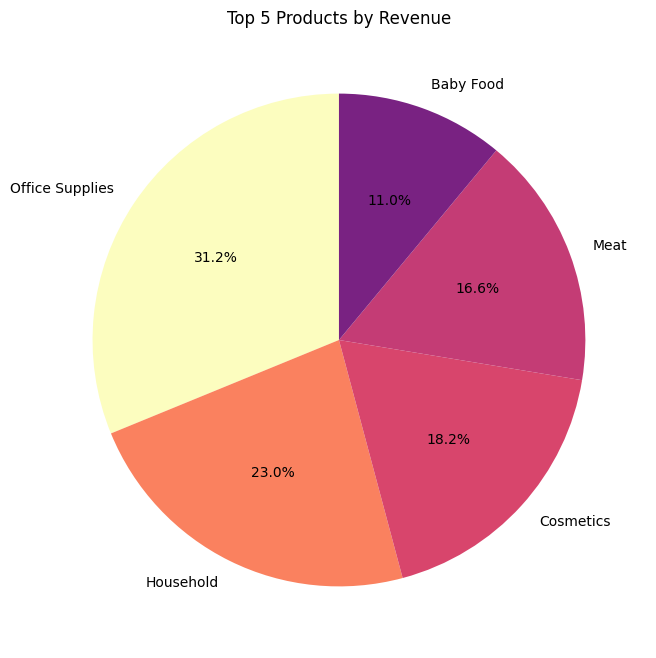

In [ ]:
import matplotlib.cm as cm
plt.figure(figsize = (8,8))
values = top_5_products_by_revenue.values
colors = cm.magma(values/values.max())
plt.pie(top_5_products_by_revenue.values, labels = top_5_products_by_revenue.index, colors = colors, autopct= '%1.1f%%', startangle = 90)
plt.title("Top 5 Products by Revenue")
plt.show()

In [ ]:
top_5_products_by_sales = full_df.groupby("Item_Type")["Units Sold"].sum().nlargest(5)
top_5_products_by_sales

,Units Sold
Item_Type,
Office Supplies,581481.0
Clothes,579313.0
Beverages,577991.0
Vegetables,532510.0
Fruits,531135.0


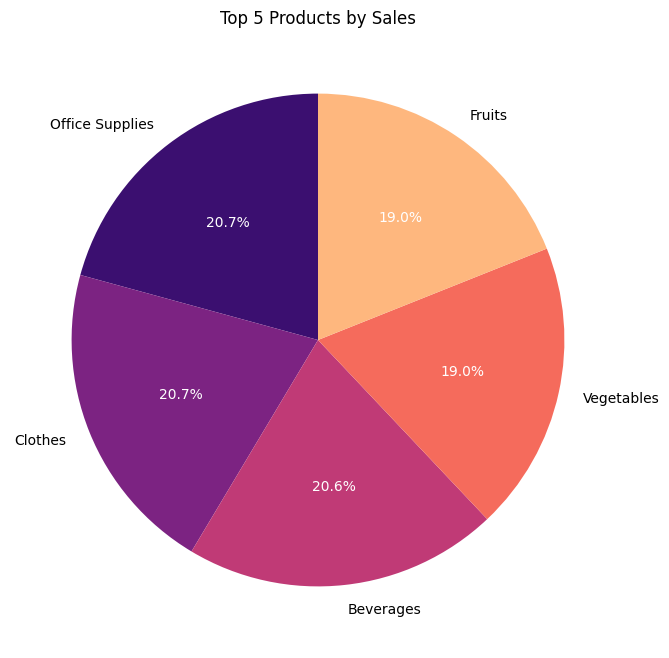

In [ ]:
plt.figure(figsize = (8,8))

values = top_5_products_by_sales.values
labels = top_5_products_by_sales.index
n = len(values)
colors = cm.magma(np.linspace(0.2, 0.85, n))
wedges, texts, autotexts = plt.pie(
    values,
    labels=labels,
    colors=colors,
    autopct='%1.1f%%',
    startangle=90
)

for text in texts:
    text.set_color('black')

for autotext in autotexts:
    autotext.set_color('#FFFFFF')
plt.title("Top 5 Products by Sales")
plt.show()

From the pie charts above, we can conclude that the leader in terms of profit and sales is the “**Office Supplies**” category. Meanwhile, sales in the top 5 categories are fairly even, although they generate different amounts of revenue.

In [ ]:
top_20_countries_by_profit = full_df.groupby("Country")["Profit"].sum().reset_index()
top_20_countries = top_20_countries_by_profit.sort_values(by = "Profit", ascending = False).head(20)
top_20_countries

,Country,Profit
4,ANDORRA,15410036.63
230,UKRAINE,14804925.74
137,MALTA,14610127.88
191,SAN MARINO,13792992.81
99,HUNGARY,13786231.03
131,MACEDONIA,13684099.95
57,CZECH REPUBLIC,13635593.78
181,RUSSIA,13267682.64
26,BOSNIA AND HERZEGOVINA,13257602.77
84,GREECE,12324450.13


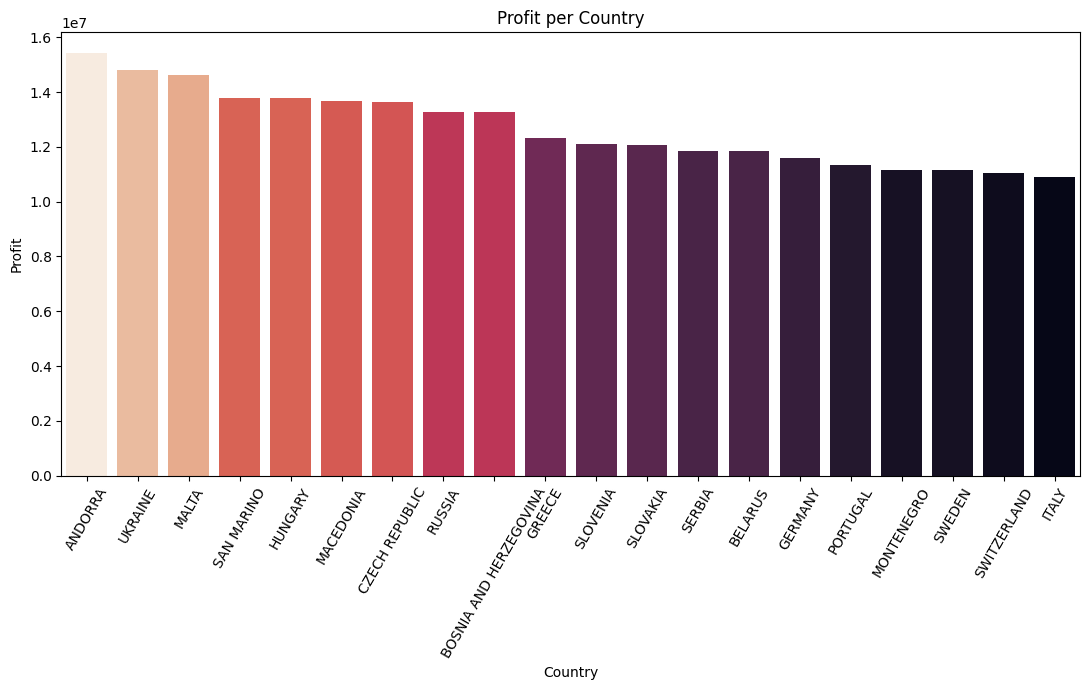

In [ ]:
plt.figure(figsize = (11,7))
sns.barplot(data = top_20_countries, x = "Country", y = "Profit", hue ="Profit", palette = "rocket", estimator = np.sum, legend = False)
plt.xticks(rotation=60)
plt.title("Profit per Country")
plt.xlabel("Country")
plt.ylabel("Profit")
plt.tight_layout()
plt.show()

/tmp/ipykernel_996/3590170394.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(data = region_profit, x = "Region", y = "Profit", palette = "magma")


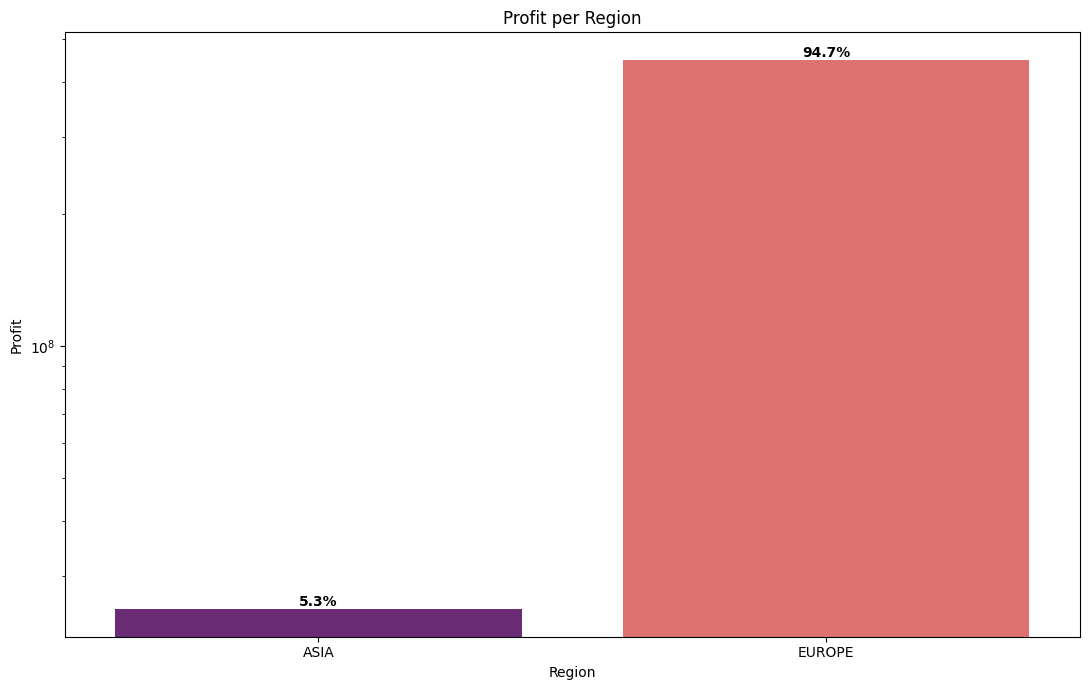

In [ ]:
plt.figure(figsize = (11,7))
region_profit = full_df.groupby("Region", as_index=False)["Profit"].sum()

region_profit = region_profit[region_profit["Profit"] > 0]

total_profit = region_profit["Profit"].sum()
region_profit["percent"] = region_profit["Profit"] / total_profit * 100

bars = sns.barplot(data = region_profit, x = "Region", y = "Profit", palette = "magma")
plt.yscale('log')
plt.title("Profit per Region")
plt.xlabel("Region")
plt.ylabel("Profit")

for bar, percent in zip(bars.patches, region_profit["percent"]):
    height = bar.get_height()
    bars.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f'{percent:.1f}%',
        ha='center',
        va='bottom',
        color='black',
        fontweight='bold'
    )
plt.tight_layout()
plt.show()

In [ ]:
regions_by_profit = full_df.groupby("Region")["Profit"].sum().reset_index()
regions_by_profit = regions_by_profit.sort_values(by = "Profit", ascending = False)

In [ ]:
regions = full_df["Region"].unique()
regions

array(['EUROPE', 'ASIA', 'AMERICAS', 'AFRICA', 'OCEANIA'], dtype=object)

The last two graphs show that the **European** market generates the largest share of profits—almost **95%** — with **Andorra, Ukraine, and Malta** in the top three countries. Asia accounts for only **5.3%**, while Asia, the Americas, Africa, and Oceania are not markets for this store's products at all.

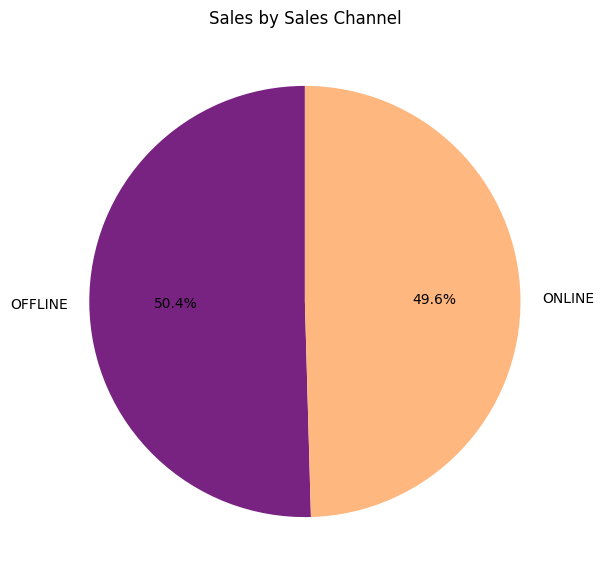

In [ ]:
sales_by_channel = full_df.groupby("Sales Channel")["Units Sold"].sum()

plt.figure(figsize = (11, 7))
labels = sales_by_channel.index
values = sales_by_channel.values
n = len(values)
colors = cm.magma(np.linspace(0.35, 0.85, n))

plt.pie(values, labels = labels, colors = colors, autopct= '%1.1f%%', startangle = 90)

plt.title("Sales by Sales Channel")
plt.show()

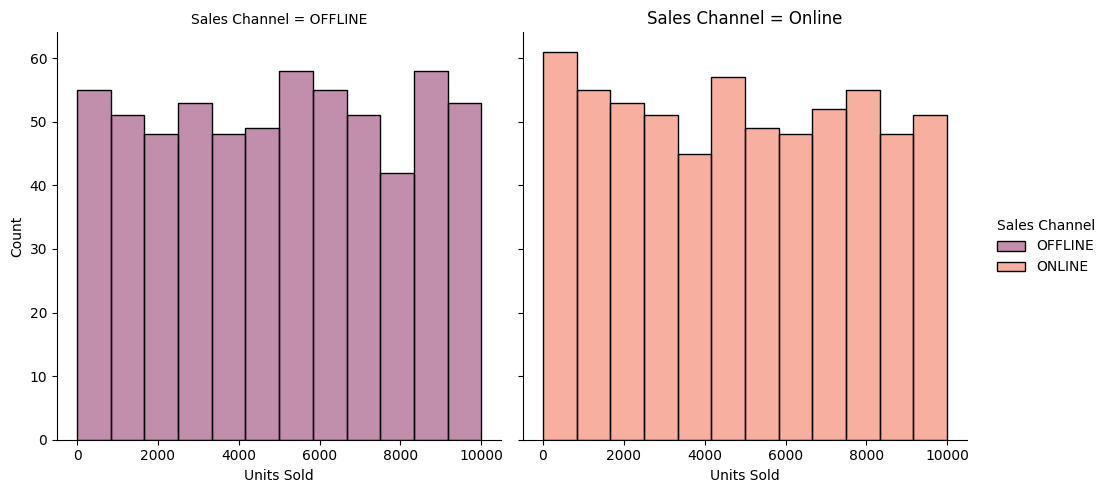

In [ ]:
sns.displot(data = full_df, x = "Units Sold", col = "Sales Channel", kind = "hist", hue = "Sales Channel", palette = "rocket",height=5, aspect=1)
plt.title("Sales Channel = Online")
plt.xlabel("Units Sold")
plt.ylabel("Count")
plt.show()

Approximately the same number of orders pass through both sales channels, but in this age of advanced technology, the **online channel** is slightly **more popular**, especially when it comes to orders of up to 3,000 units.

In [ ]:
full_df["Span"] = full_df["Ship Date"] - full_df["Order Date"]
full_df

,Order ID,Order Date,Ship Date,Order Priority,Country Code,Product ID,Sales Channel,Units Sold,Unit Price,Unit Cost,Country,Region,Sub-Region,Item_Type,Revenue,Cost,Profit,Span
0,270358788.0,2014-12-11,2015-01-24,M,ALB,1270.0,OFFLINE,4028.0,47.45,31.79,ALBANIA,EUROPE,SOUTHERN EUROPE,Beverages,191128.60,128050.12,63078.48,44 days
1,833473765.0,2013-04-28,2013-05-25,H,ALB,1270.0,OFFLINE,2264.0,47.45,31.79,ALBANIA,EUROPE,SOUTHERN EUROPE,Beverages,107426.80,71972.56,35454.24,27 days
2,877062451.0,2012-10-09,2012-10-29,C,ALB,1270.0,ONLINE,1124.0,47.45,31.79,ALBANIA,EUROPE,SOUTHERN EUROPE,Beverages,53333.80,35731.96,17601.84,20 days
3,320431125.0,2015-03-11,2015-04-17,H,AND,1270.0,ONLINE,1545.0,47.45,31.79,ANDORRA,EUROPE,SOUTHERN EUROPE,Beverages,73310.25,49115.55,24194.70,37 days
4,378873240.0,2012-11-25,2012-11-28,H,AND,1270.0,ONLINE,5866.0,47.45,31.79,ANDORRA,EUROPE,SOUTHERN EUROPE,Beverages,278341.70,186480.14,91861.56,3 days
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1443,NaN,NaT,NaT,NaN,WSM,NaN,NaN,NaN,NaN,NaN,SAMOA,OCEANIA,POLYNESIA,NaN,NaN,NaN,NaN,NaT
1444,NaN,NaT,NaT,NaN,YEM,NaN,NaN,NaN,NaN,NaN,YEMEN,ASIA,WESTERN ASIA,NaN,NaN,NaN,NaN,NaT
1445,NaN,NaT,NaT,NaN,ZAF,NaN,NaN,NaN,NaN,NaN,SOUTH AFRICA,AFRICA,SUBSAHARAN AFRICA,NaN,NaN,NaN,NaN,NaT
1446,NaN,NaT,NaT,NaN,ZMB,NaN,NaN,NaN,NaN,NaN,ZAMBIA,AFRICA,SUBSAHARAN AFRICA,NaN,NaN,NaN,NaN,NaT


In [ ]:
full_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1448 entries, 0 to 1447
Data columns (total 18 columns):
 #   Column          Non-Null Count  Dtype          
---  ------          --------------  -----          
 0   Order ID        1246 non-null   float64        
 1   Order Date      1246 non-null   datetime64[ns] 
 2   Ship Date       1246 non-null   datetime64[ns] 
 3   Order Priority  1246 non-null   object         
 4   Country Code    1448 non-null   object         
 5   Product ID      1246 non-null   float64        
 6   Sales Channel   1246 non-null   object         
 7   Units Sold      1246 non-null   float64        
 8   Unit Price      1246 non-null   float64        
 9   Unit Cost       1246 non-null   float64        
 10  Country         1448 non-null   object         
 11  Region          1448 non-null   object         
 12  Sub-Region      1448 non-null   object         
 13  Item_Type       1246 non-null   object         
 14  Revenue         1246 non-null   float64 

In [ ]:
full_df["Span_Day"]=full_df["Span"].dt.days

In [ ]:
mean_span_by_categories = full_df.groupby("Item_Type")["Span_Day"].mean().reset_index()
mean_span_by_categories_sorted = mean_span_by_categories.sort_values(by = "Span_Day", ascending = False)
mean_span_by_categories_sorted

,Item_Type,Span_Day
8,Office Supplies,27.283186
2,Cereal,27.198020
0,Baby Food,26.647619
4,Cosmetics,25.879630
7,Meat,25.735294
10,Snacks,25.263158
5,Fruits,24.475728
11,Vegetables,24.438095
1,Beverages,23.946903
6,Household,23.571429


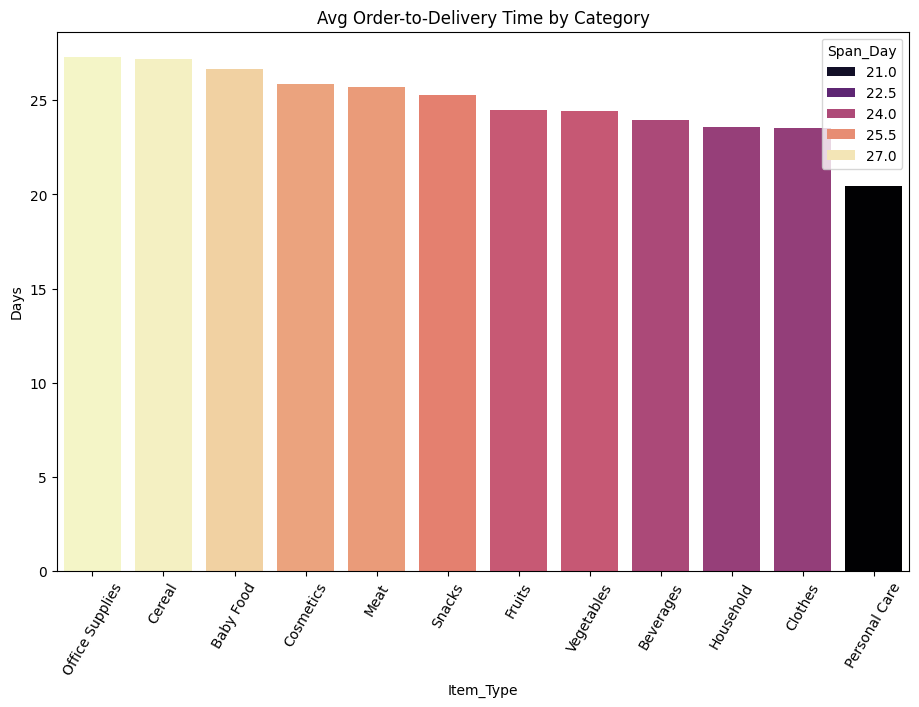

In [ ]:
plt.figure(figsize = (11,7))
sns.barplot(data = mean_span_by_categories_sorted, x = "Item_Type", y = "Span_Day", hue ="Span_Day", palette = "magma",)
plt.xticks(rotation=60)
plt.title("Avg Order-to-Delivery Time by Category")
plt.xlabel("Item_Type")
plt.ylabel("Days")
plt.show()

The bar chart shows us that, on average, it takes the longest to prepare for shipment for **Office Supplies**, **Cereal**, and **Baby Food** items—approximately **27** days. The fastest items to ship after ordering are in the **Personal Care** category—**20** days.

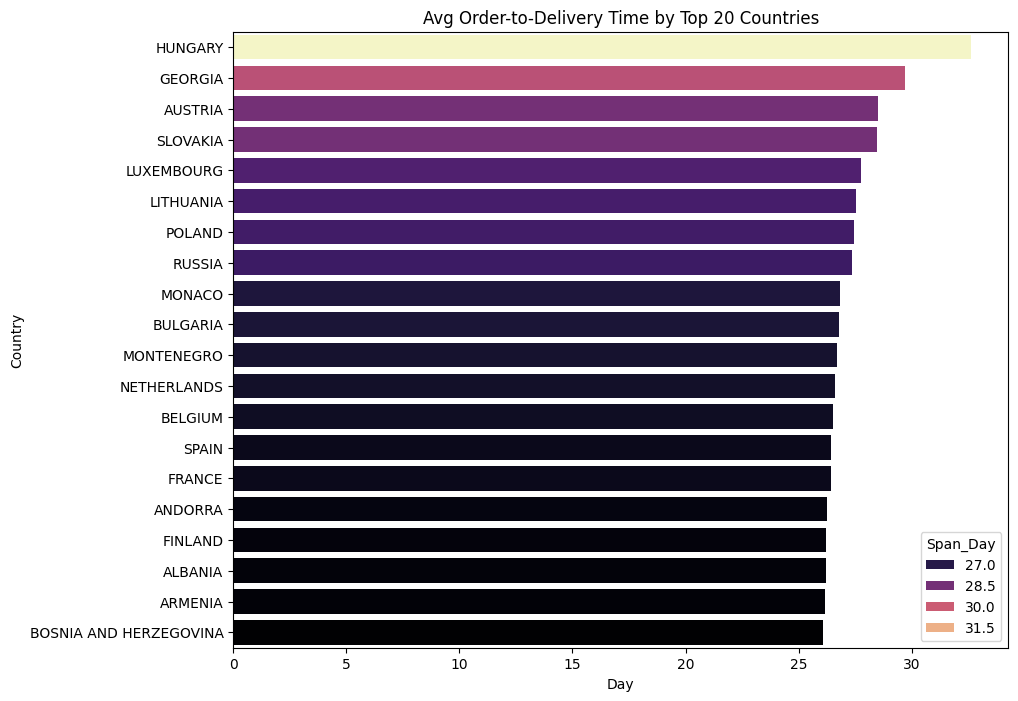

In [ ]:

top_20_countries_by_span = full_df.groupby("Country")["Span_Day"].mean().reset_index()
top_20_countries_span = top_20_countries_by_span.sort_values(by = "Span_Day", ascending = False).head(20)
top_20_countries_span

plt.figure(figsize=(10,8))
sns.barplot(data=top_20_countries_span, y="Country", x="Span_Day", hue = "Span_Day", palette="magma")
plt.xlabel("Day")
plt.ylabel("Country")
plt.title("Avg Order-to-Delivery Time by Top 20 Countries")
plt.show()


The shortest time between ordering goods and shipping is **27** days on average for **Bosnia and Herzegovina**, while the longest period was **31** days for **Hungary**.

In [ ]:
mean_span_by_sub_regions = full_df.groupby("Sub-Region")["Span_Day"].mean().reset_index()
mean_span_by_sub_regions_sorted = mean_span_by_sub_regions.sort_values(by = "Span_Day", ascending = False)
mean_span_by_sub_regions_sorted

,Sub-Region,Span_Day
3,EASTERN EUROPE,26.959410
15,WESTERN ASIA,26.085366
16,WESTERN EUROPE,25.883408
13,SOUTHERN EUROPE,23.880779
9,NORTHERN EUROPE,23.023166
0,AUSTRALIA AND NEW ZEALAND,NaN
1,CENTRAL ASIA,NaN
2,EASTERN ASIA,NaN
4,LATIN AMERICA AND THE CARIBBEAN,NaN
5,MELANESIA,NaN


In [ ]:
mean_span_by_sub_regions_sorted.dropna(inplace = True)

In [ ]:
mean_span_by_sub_regions_sorted

,Sub-Region,Span_Day
3,EASTERN EUROPE,26.959410
15,WESTERN ASIA,26.085366
16,WESTERN EUROPE,25.883408
13,SOUTHERN EUROPE,23.880779
9,NORTHERN EUROPE,23.023166


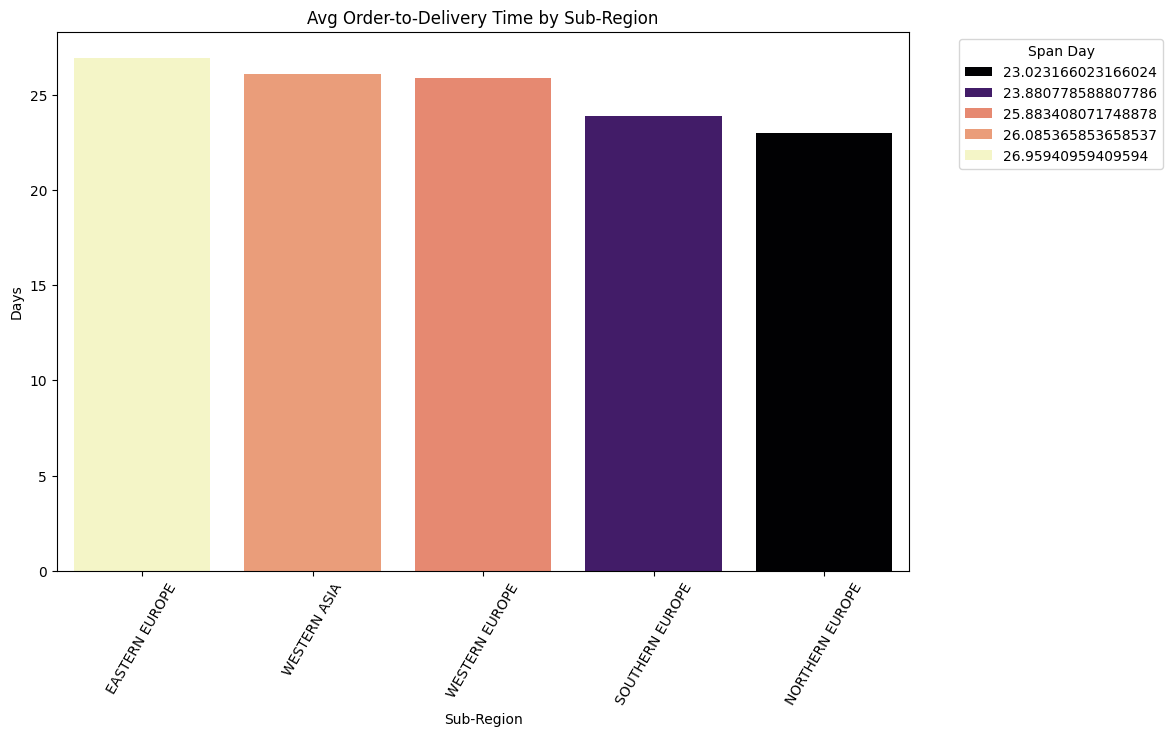

In [ ]:
plt.figure(figsize = (11,7))
sns.barplot(data = mean_span_by_sub_regions_sorted, x = "Sub-Region", y = "Span_Day", hue ="Span_Day", palette = "magma",)
plt.xticks(rotation=60)
plt.title("Avg Order-to-Delivery Time by Sub-Region")
plt.legend(title="Span Day",bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xlabel("Sub-Region")
plt.ylabel("Days")
plt.show()

The graph above shows that the **longest** process of preparing goods for shipment occurs in the **Eastern Europe** subregion, as we have already seen from the penultimate graph, and the **fastest** in **Northern Europe**.

In [ ]:
full_df[["Span_Day", "Profit"]].corr()

,Span_Day,Profit
Span_Day,1.000000,0.060695
Profit,0.060695,1.000000


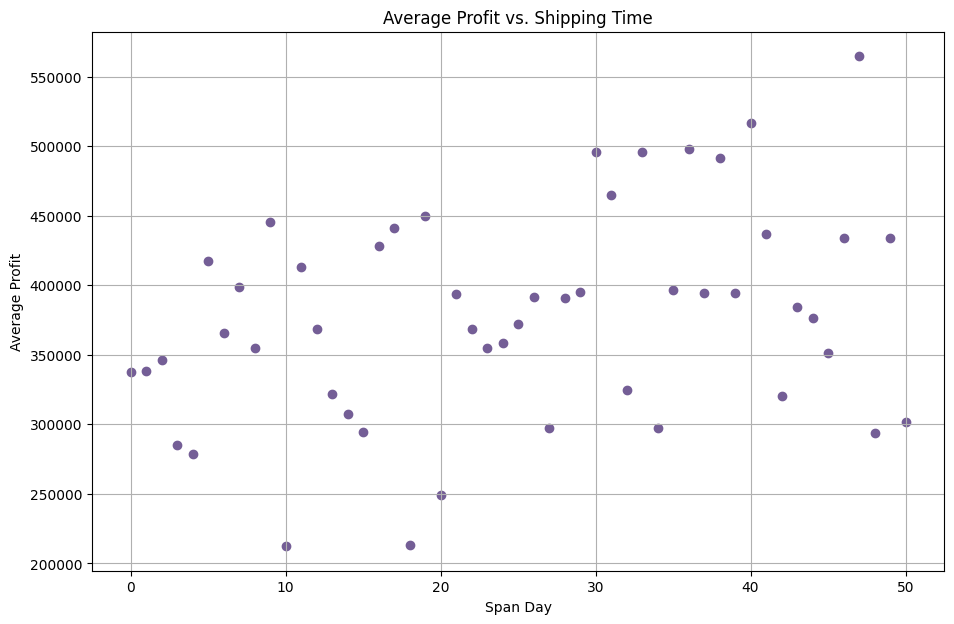

In [ ]:
mean_profit_by_span = (full_df.groupby("Span_Day", as_index=False)["Profit"].mean())

plt.figure(figsize=(11, 7))
plt.scatter(mean_profit_by_span["Span_Day"], mean_profit_by_span["Profit"], alpha=1, color = "#745E96")
plt.xlabel("Span Day")
plt.ylabel("Average Profit")
plt.title("Average Profit vs. Shipping Time")
plt.grid(True)
plt.show()

The above analysis tells us that there is **no correlation** between *profit* and *the time* required to ship goods. No trend can be observed; with equally high profit figures, the time required to ship goods can be either short or long. The correlation coefficient is 0.06, which is very low for any correlation.

<Figure size 1100x600 with 0 Axes>

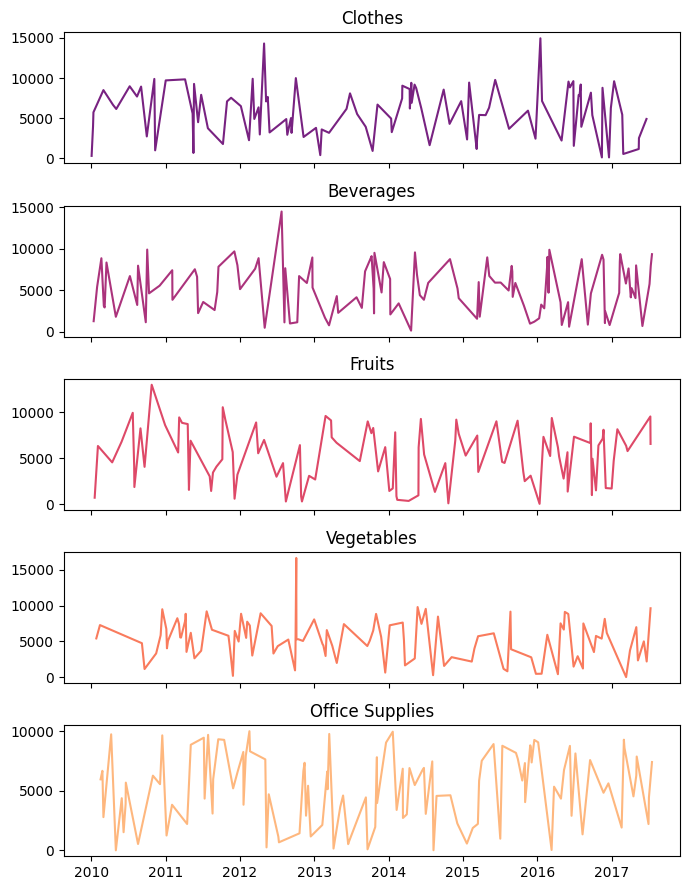

In [ ]:
plt.figure(figsize=(11, 6))

time_series_data_top_5 =(full_df[full_df["Item_Type"].isin(top_5_products_by_sales.index)].groupby(["Order Date", "Item_Type"], as_index=False)["Units Sold"].sum())

colors = cm.magma(np.linspace(0.35, 0.85, 5))
fig, axes = plt.subplots(5, 1, figsize=(7, 9), sharex=True)
for ax, cat, color in zip(axes, time_series_data_top_5["Item_Type"].unique(), colors):
    cat_data = time_series_data_top_5[
        time_series_data_top_5["Item_Type"] == cat
    ]

    ax.plot(cat_data["Order Date"], cat_data["Units Sold"], color = color, label=cat)
    ax.set_title(cat)
plt.tight_layout()
plt.show()

The trend in the top 5 product categories above indicates that some products are seasonal, especially fruits and vegetables. There is also a visible downward trend in demand for fruits at the end of 2017 and an increase in sales in the other 4 product categories.

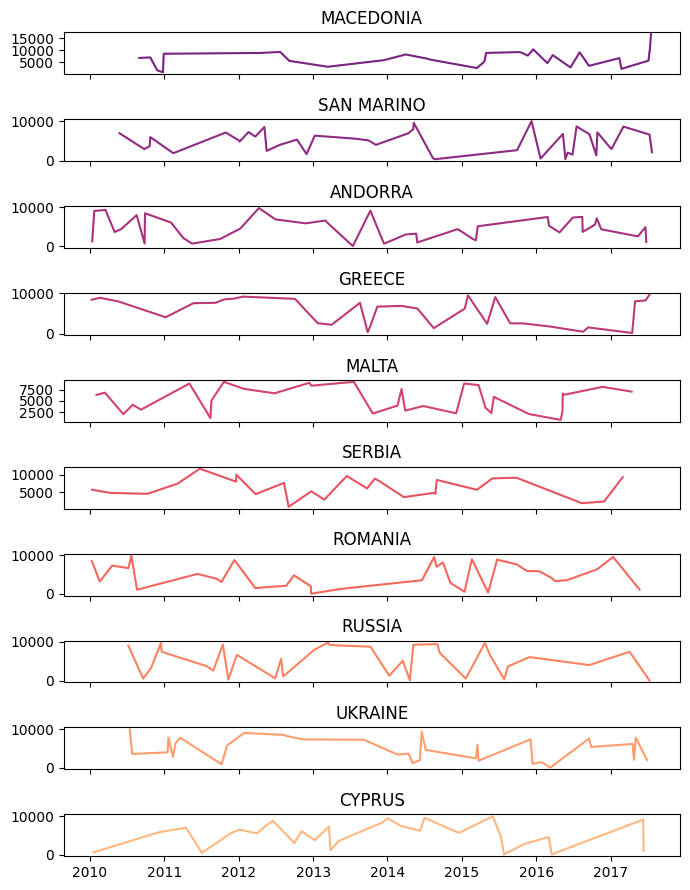

In [ ]:
top_10_countries_by_sales = (
    full_df
    .groupby("Country")["Units Sold"]
    .sum()
    .nlargest(10)
)
time_series_data_top_10 = ( full_df[full_df["Country"].isin(top_10_countries_by_sales.index)]
    .groupby(["Order Date", "Country"], as_index=False)["Units Sold"]
    .sum())
colors = cm.magma(np.linspace(0.35, 0.85, 10))
fig, axes = plt.subplots(10, 1, figsize=(7, 9), sharex=True)
for ax, count, color in zip(axes, top_10_countries_by_sales.index, colors):
    data = time_series_data_top_10[
        time_series_data_top_10["Country"] == count
    ]
    ax.plot(data["Order Date"], data["Units Sold"], color = color)
    ax.set_title(count)

plt.tight_layout()
plt.show()

At the end of the period for which we have data, there was a decline in demand for goods in San Marino, Romania, Andorra, Russia, Ukraine, and Cyprus, which are among the top 10 countries in terms of sales volume. Other countries showed a clear trend toward growth or stable sales levels.

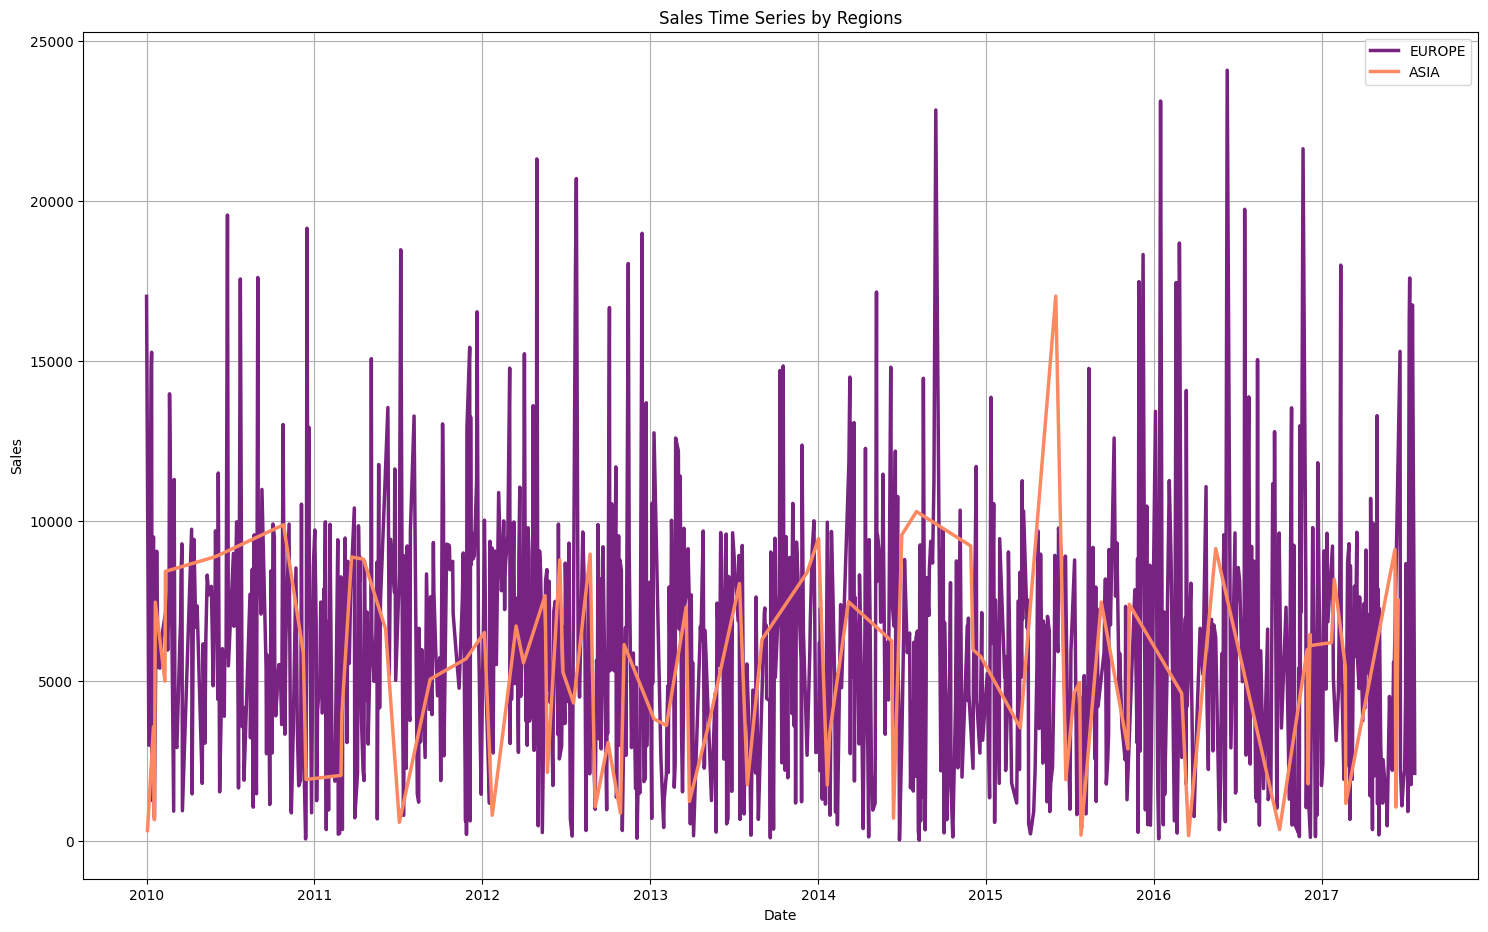

In [ ]:
time_series_data_by_region = (full_df
    .groupby(["Order Date", "Region"])["Units Sold"]
    .sum()
    .reset_index()
)

plt.figure(figsize=(18, 11))
colors = cm.magma(np.linspace(0.35, 0.75, 2))
regions = time_series_data_by_region["Region"].unique()
for reg, color in zip(regions, colors):
    regions_data = time_series_data_by_region[time_series_data_by_region["Region"] == reg]
    plt.plot(regions_data["Order Date"], regions_data["Units Sold"], label=reg, color = color, linewidth=2.5)

plt.xlabel("Date")
plt.ylabel("Sales")
plt.title("Sales Time Series by Regions")
plt.legend()
plt.grid(True)
plt.show()

The graph above clearly shows that Europe is the main buyer of goods in this store, while in Asia, demand for goods periodically falls and then rises. In the first half of 2015, there was the highest jump in sales to Asia.

In [ ]:
full_df["Day_Of_Week"] = full_df["Order Date"].dt.day_name()

In [ ]:
full_df.head()

,Order ID,Order Date,Ship Date,Order Priority,Country Code,Product ID,Sales Channel,Units Sold,Unit Price,Unit Cost,Country,Region,Sub-Region,Item_Type,Revenue,Cost,Profit,Span,Span_Day,Day_Of_Week
0,270358788.0,2014-12-11,2015-01-24,M,ALB,1270.0,OFFLINE,4028.0,47.45,31.79,ALBANIA,EUROPE,SOUTHERN EUROPE,Beverages,191128.60,128050.12,63078.48,44 days,44.0,Thursday
1,833473765.0,2013-04-28,2013-05-25,H,ALB,1270.0,OFFLINE,2264.0,47.45,31.79,ALBANIA,EUROPE,SOUTHERN EUROPE,Beverages,107426.80,71972.56,35454.24,27 days,27.0,Sunday
2,877062451.0,2012-10-09,2012-10-29,C,ALB,1270.0,ONLINE,1124.0,47.45,31.79,ALBANIA,EUROPE,SOUTHERN EUROPE,Beverages,53333.80,35731.96,17601.84,20 days,20.0,Tuesday
3,320431125.0,2015-03-11,2015-04-17,H,AND,1270.0,ONLINE,1545.0,47.45,31.79,ANDORRA,EUROPE,SOUTHERN EUROPE,Beverages,73310.25,49115.55,24194.70,37 days,37.0,Wednesday
4,378873240.0,2012-11-25,2012-11-28,H,AND,1270.0,ONLINE,5866.0,47.45,31.79,ANDORRA,EUROPE,SOUTHERN EUROPE,Beverages,278341.70,186480.14,91861.56,3 days,3.0,Sunday


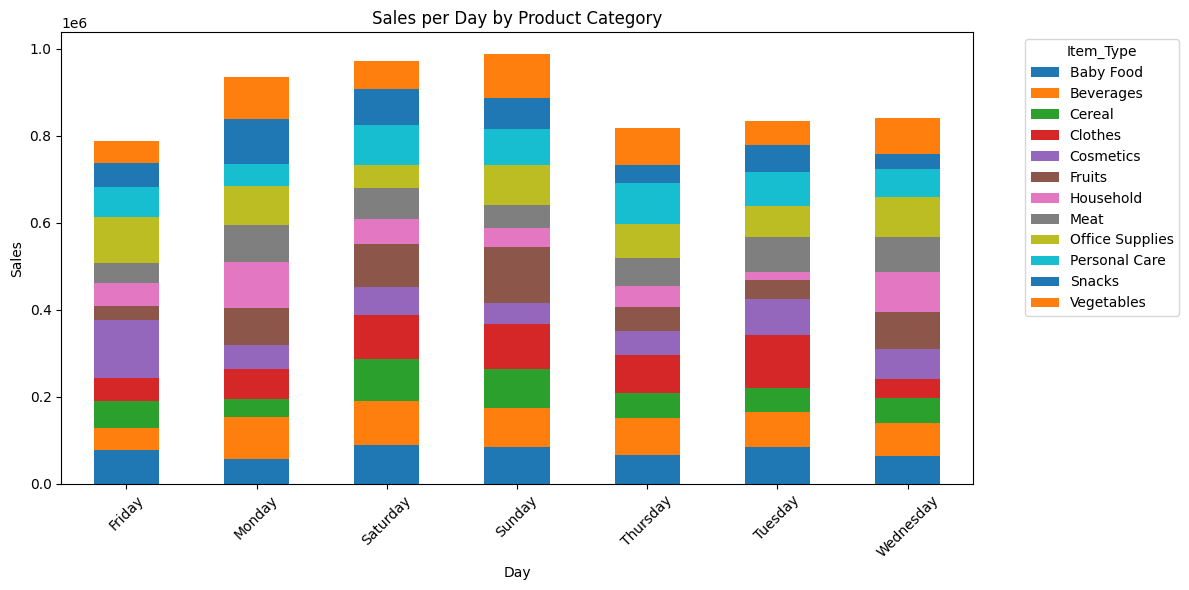

In [ ]:
day_of_week_sales = full_df.groupby(["Day_Of_Week","Item_Type"])["Units Sold"].sum().unstack()
day_of_week_sales.plot(kind = "bar", stacked = True,figsize=(12, 6))

plt.xlabel("Day")
plt.ylabel("Sales")
plt.title("Sales per Day by Product Category")
plt.legend(title="Item_Type",bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

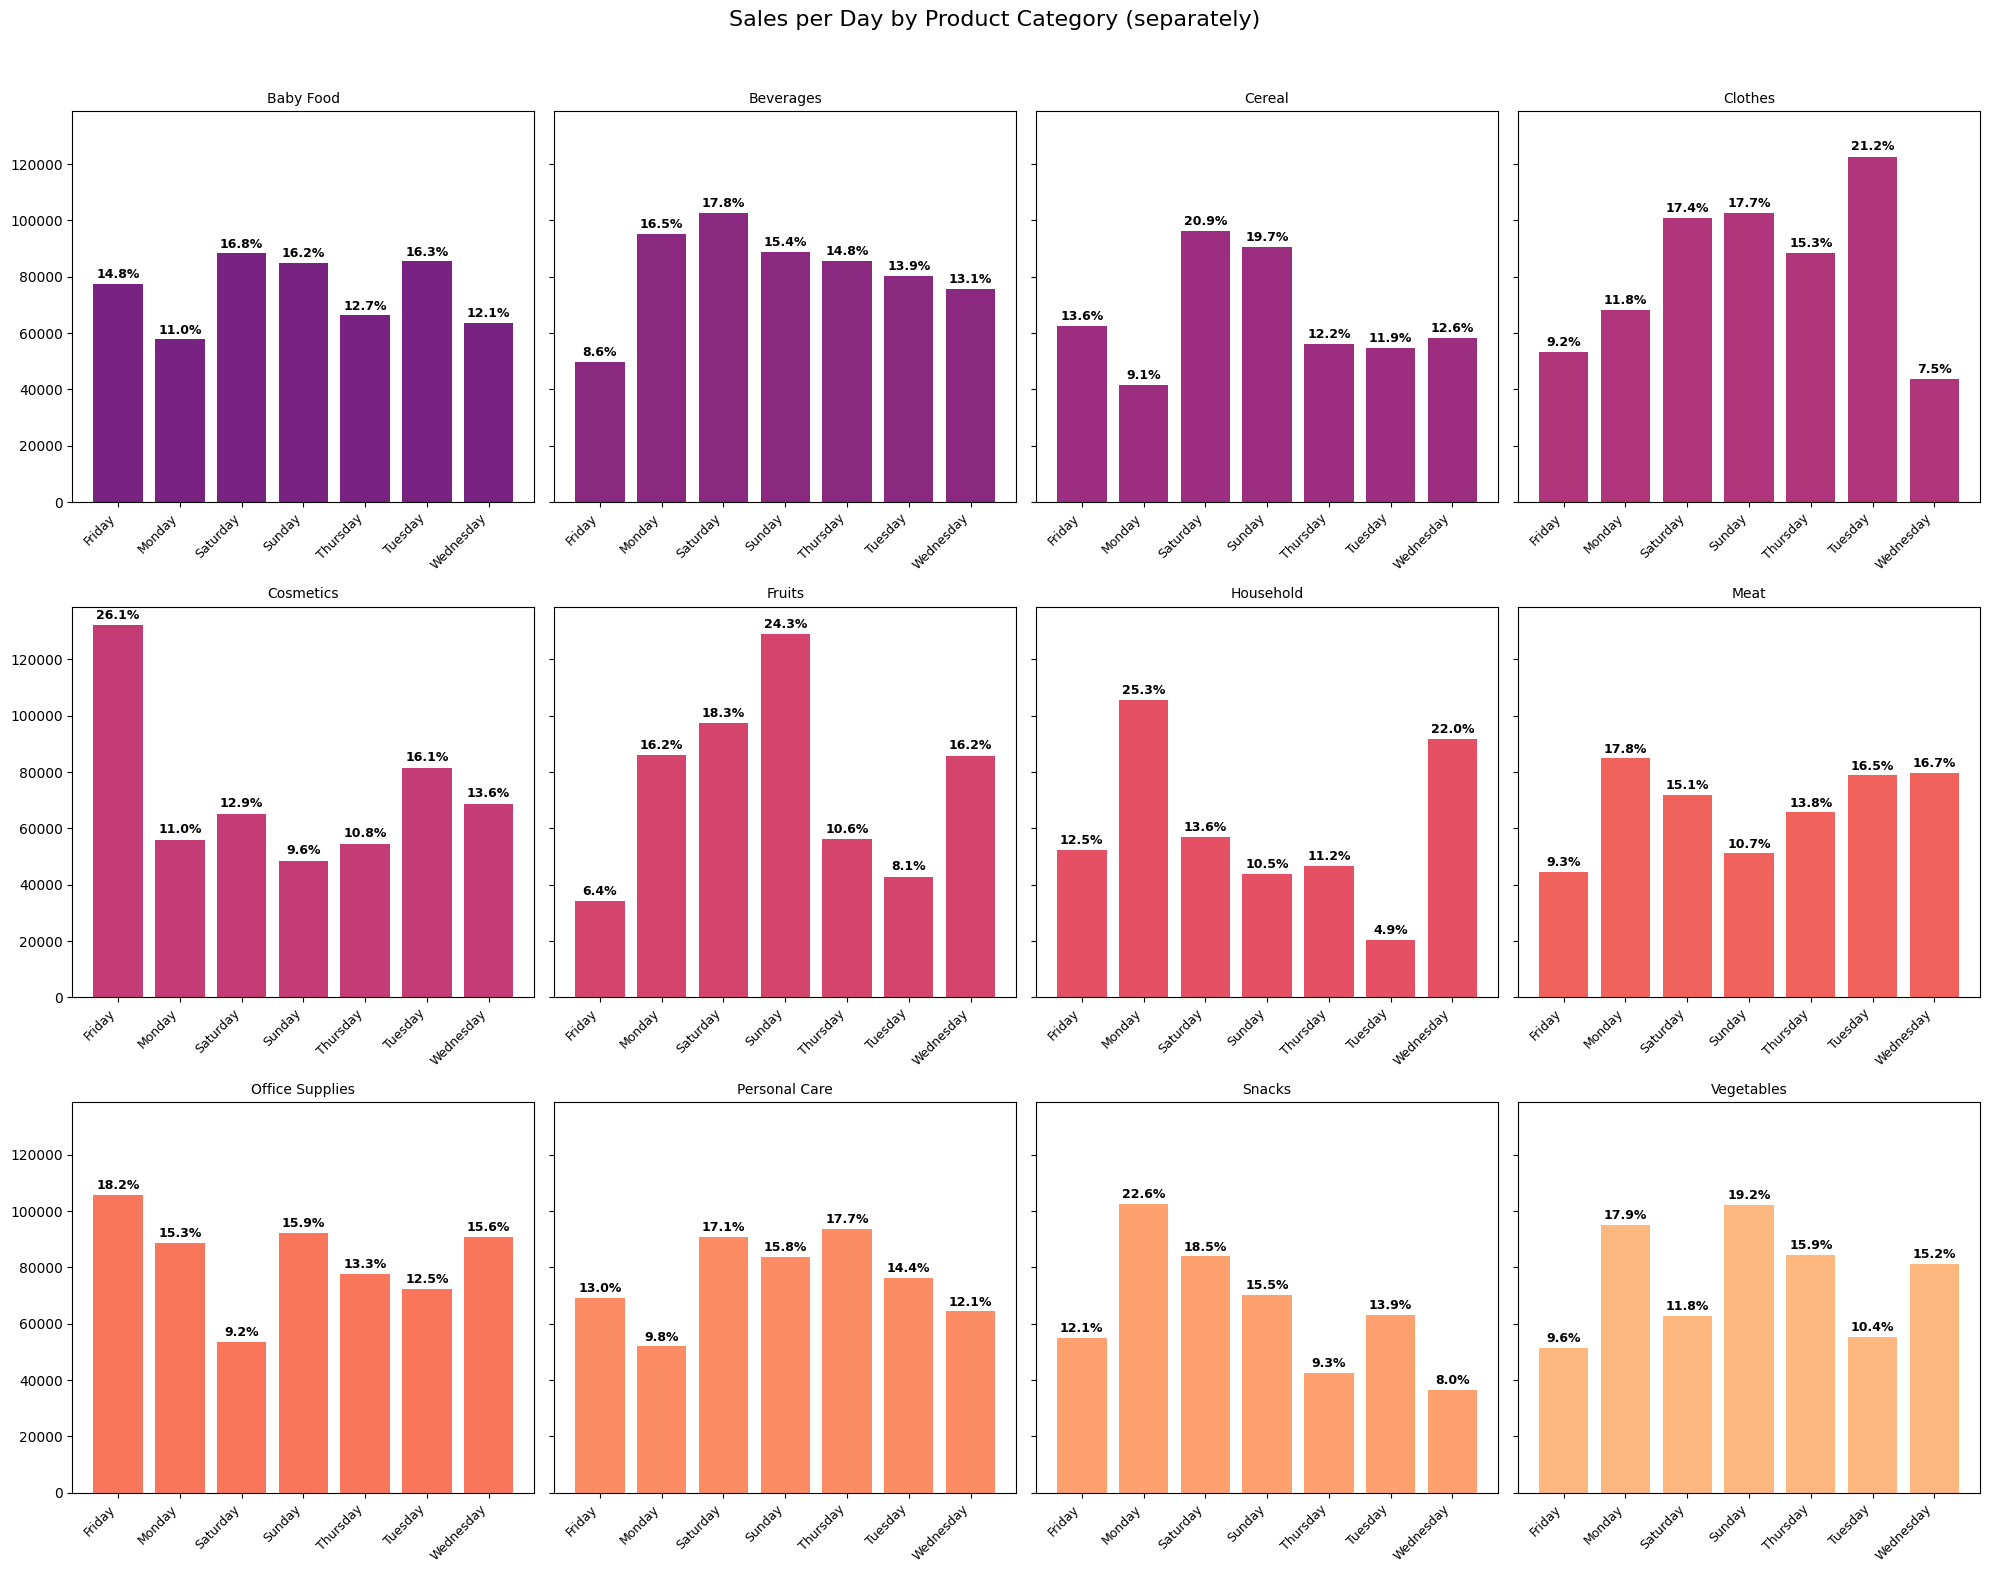

In [ ]:


categories = day_of_week_sales.columns
n_categories = len(categories)

n_rows = 3
n_cols = 4

colors = cm.magma(np.linspace(0.35, 0.85, n_categories))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 16), sharey=True)

for i, (category, color) in enumerate(zip(categories, colors)):
    row = i // n_cols
    col = i % n_cols
    ax = axes[row, col]

    ax.bar(day_of_week_sales.index, day_of_week_sales[category], color=color)

    ax.set_title(category, fontsize=10)

    ax.set_xticks(range(len(day_of_week_sales.index)))
    ax.set_xticklabels(day_of_week_sales.index, rotation=45, ha='right', fontsize=9)


    total = day_of_week_sales[category].sum()
    for j, value in enumerate(day_of_week_sales[category]):
        if total > 0:
            percent = value / total * 100
            ax.text(j, value + max(day_of_week_sales[category])*0.01,
                    f'{percent:.1f}%', ha='center', va='bottom',
                    color='black', fontsize=9, fontweight='bold')

for k in range(n_categories, n_rows * n_cols):
    fig.delaxes(axes.flatten()[k])

fig.suptitle("Sales per Day by Product Category (separately)", fontsize=16)
fig.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


In the penultimate graph, we see that the **most popular** days for purchases are **Sunday** and **Saturday**.
The graphs below show the sales characteristics for each category separately. The following products stand out from the overall picture: Office Supplies and Cosmetics, for which the most popular day for sales is Friday; Personal Care and Clothes, for which the most popular day is Thursday; and Snacks, Meat, and Household, for which the highest sales occur on Monday.
Seasonal goods include Cosmetics, Fruits, Household, and Clothes. All other goods are sold evenly throughout the week on average.

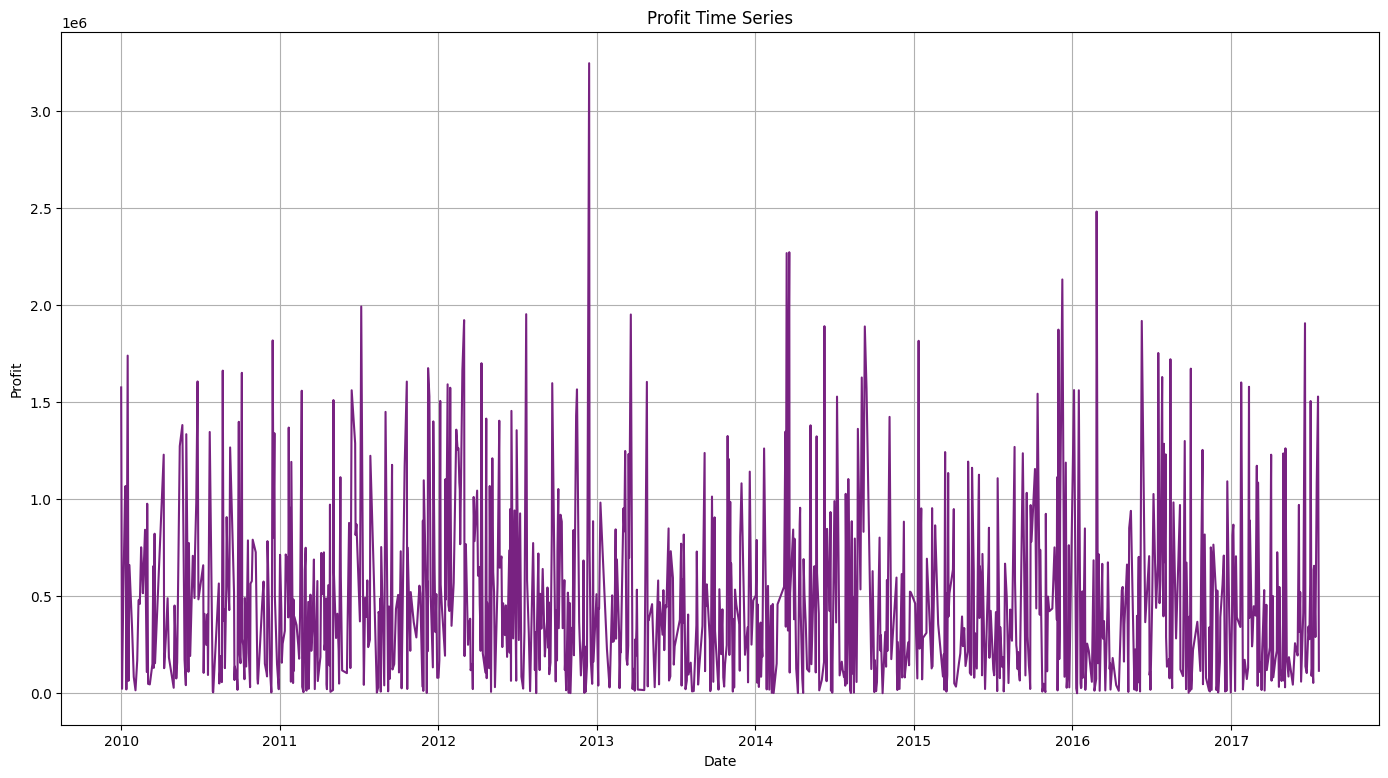

In [ ]:

time_series_data_profit = (
    full_df.groupby(["Order Date"])["Profit"].sum().reset_index()
)
colors = cm.magma(np.linspace(0.35, 0.75, 2))
plt.figure(figsize=(17, 9))
plt.plot(time_series_data_profit["Order Date"], time_series_data_profit["Profit"], color = colors[0])

plt.xlabel("Date")
plt.ylabel("Profit")
plt.title("Profit Time Series")
plt.grid(True)
plt.show()


The graph above shows that **sales** at this store are **falling**, repeating the trends of previous years. There are several possible options for improving the situation of this business.
- The store can **expand** its **sales markets** - not only Europe and Asia, but also countries on other continents.
- For seasonal goods by day of the week (*Sales per Day by Product Category*) *(separately*) **launch discounts** on days when demand for these goods falls, thereby evening out the weekly sales trend and reducing the workload on employees on peak days.
- Since the interval between ordering and shipping has absolutely no bearing on profit margins, no adjustments are needed in this sector.
- **Increase** the volume of **sales** of goods such as **Household, Cosmetics, Meat, and Baby Food**, as they are the main source of profit and are among the top 5 goods, while the top 5 in terms of sales include completely different categories.